#  CONFIGURAÇÃO INICIAL E IMPORTAÇÕES

In [1]:
# Instalações necessárias
!apt-get install -y openjdk-8-jdk-headless > /dev/null
!pip install -q findspark pyspark==3.5.0 folium seaborn plotly matplotlib ipywidgets scikit-learn

# Configuração do ambiente
import os
import findspark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
findspark.init()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.9 MB/s eta 0:00:00


In [2]:
# Importações principais
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, year, month, dayofmonth, count, desc, sum as _sum, avg, monotonically_increasing_id
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, PCA, Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Visualização e utilitários
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import ipywidgets as widgets
from IPython.display import display, clear_output
import pickle


# INICIALIZAÇÃO DO SPARK E CARREGAMENTO DOS DADOS

O Spark foi escolhido por sua capacidade de processamento distribuído, essencial para
análise de grandes volumes de dados. A versão 3.5.0 oferece estabilidade e compatibilidade
com todas as bibliotecas que utilizaremos.

In [3]:
# Criação da Spark Session
spark = SparkSession.builder \
    .appName("Analise de IST") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("Apache Spark configurado e iniciado!")
print("Versão do Spark:", spark.version)


Apache Spark configurado e iniciado!
Versão do Spark: 3.5.0


In [6]:
# Primeiro, montamos o Google Drive para conseguir acessar o arquivo CSV que contém os dados que serão utilizados na análise.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Definimos o caminho do arquivo CSV dentro do Google Drive.
# É importante que o caminho esteja correto para evitar erros na leitura.
file_path = '/content/drive/MyDrive/dados_ist_tratados.csv'

# Utilizamos o Spark para fazer a leitura do arquivo CSV.
# Colocamos a opção header=True para que a primeira linha do arquivo seja reconhecida como cabeçalho (nomes das colunas).
# E inferSchema=True para que o Spark identifique automaticamente os tipos de dados de cada coluna.
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

In [8]:
# Visualização inicial
print("\nSchema do DataFrame:")
spark_df.printSchema()
print("\nPrimeiras 5 linhas:")
spark_df.show(5)


Schema do DataFrame:
root
 |-- id: string (nullable = true)
 |-- nome: string (nullable = true)
 |-- genero: string (nullable = true)
 |-- idade: integer (nullable = true)
 |-- doenca: string (nullable = true)
 |-- localidade: string (nullable = true)
 |-- nivel_educacional: string (nullable = true)
 |-- renda_media: integer (nullable = true)
 |-- data_teste: date (nullable = true)


Primeiras 5 linhas:
+--------------------+----------------+---------+-----+--------+--------------+-----------------+-----------+----------+
|                  id|            nome|   genero|idade|  doenca|    localidade|nivel_educacional|renda_media|data_teste|
+--------------------+----------------+---------+-----+--------+--------------+-----------------+-----------+----------+
|e5e6c50e-1170-40d...| Thiago Nogueira|Masculino|   22|Clamídia|      Anápolis|      Fundamental|       1857|2024-06-05|
|66dc588a-4c51-449...|     Felipe Rios|Masculino|   61| Nenhuma|      Anápolis|         Superior|       3096

# PRÉ-PROCESSAMENTO DOS DADOS
O pré-processamento é essencial para garantir a qualidade dos dados antes da modelagem.
Inclui tratamento de valores ausentes, codificação de variáveis categóricas e criação
de features derivadas que podem ser úteis para os modelos.

In [10]:
# Listas para classificação de doenças
ists = ["HIV", "Sífilis", "Gonorreia", "HPV", "Clamídia", "Herpes Genital"]
curaveis = ["Sífilis", "Gonorreia", "Clamídia"]

# Criar colunas binárias para IST e doenças curáveis
spark_df = spark_df.withColumn("tem_ist", when(col("doenca").isin(ists), 1).otherwise(0))
spark_df = spark_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

In [64]:
# Indexação e codificação de variáveis categóricas
#Etapa 1: Indexação de colunas categóricas
# O StringIndexer transforma categorias em números inteiros.
# O parâmetro handleInvalid='keep' garante que, se houver valores não reconhecidos, eles não causarão erro e serão tratados.

indexers = [
    StringIndexer(inputCol="genero", outputCol="generoIdx", handleInvalid="keep"),
    StringIndexer(inputCol="doenca", outputCol="doencaIdx", handleInvalid="keep"),
    StringIndexer(inputCol="localidade", outputCol="localidadeIdx", handleInvalid="keep"),
    StringIndexer(inputCol="nivel_educacional", outputCol="nivelEducacionalIdx", handleInvalid="keep")
]

## OneHotEncoder para transformar os indexadores
# Etapa 2: OneHotEncoder para variáveis categóricas
# O OneHotEncoder cria vetores binários para cada categoria,
# evitando que o modelo interprete uma ordem inexistente entre categorias.

encoders = [
    OneHotEncoder(inputCol="generoIdx", outputCol="generoVec"),
    OneHotEncoder(inputCol="doencaIdx", outputCol="doencaVec"),
    OneHotEncoder(inputCol="localidadeIdx", outputCol="localidadeVec"),
    OneHotEncoder(inputCol="nivelEducacionalIdx", outputCol="nivelEducacionalVec")
]

In [62]:
# Montagem do vetor de features
## Etapa 3: Montagem do vetor de features
# O VectorAssembler reúne todas as variáveis numéricas e categóricas codificadas
# em uma única coluna chamada 'features', que será utilizada pelos modelos.
assembler = VectorAssembler(
    inputCols=["idade", "renda_media", "generoVec", "doencaVec", "localidadeVec", "nivelEducacionalVec"],
    outputCol="features"
)

# Pipeline completo de pré-processamento
# Etapa 4: Criação do pipeline de transformação
# O pipeline automatiza as etapas de indexação, codificação e montagem do vetor de features.
pipeline = Pipeline(stages=indexers + encoders + [assembler])
model = pipeline.fit(spark_df)
encoded_df = model.transform(spark_df)


# Criar coluna binária 'tem_ist': 1 se é uma IST, 0 se não
# Etapa 5: Criação da coluna binária 'tem_ist'
# Criamos uma variável alvo que indica se a pessoa possui ou não uma IST.
# A condição é: se a coluna 'doenca' for diferente de "Nenhuma", então tem IST (1), senão não tem (0).

encoded_df = encoded_df.withColumn("tem_ist", when(col("doenca").isin(ists), 1).otherwise(0))

# Criar coluna binária 'curavel': 1 se é curável, 0 se não (só nas ISTs)
encoded_df = encoded_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

In [14]:
# Visualização dos dados após pré-processamento
print("\nDados após pré-processamento:")
encoded_df.select("id", "idade", "renda_media", "genero", "localidade", "doenca", "tem_ist", "curavel").show(5)


Dados após pré-processamento:
+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
|                  id|idade|renda_media|   genero|    localidade|  doenca|tem_ist|curavel|
+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
|e5e6c50e-1170-40d...|   22|       1857|Masculino|      Anápolis|Clamídia|      1|      1|
|66dc588a-4c51-449...|   61|       3096|Masculino|      Anápolis| Nenhuma|      0|      0|
|c0e0dff7-b5ee-44a...|   71|       5499| Feminino|    Rio Branco| Nenhuma|      0|      0|
|28a85f7c-ab6d-447...|   71|       1201| Feminino|            NA| Nenhuma|      0|      0|
|344150b1-6a7c-42f...|   23|       1291|Masculino|Ribeirão Preto|    Asma|      0|      0|
+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
only showing top 5 rows



# PROCESSAMENTO DE LINGUAGEM NATURAL (PLN)
Aplicamos técnicas de PLN na coluna 'doenca' para extrair informações adicionais
dos textos. O TF-IDF é uma técnica eficaz para representar textos de forma numérica,
permitindo análises quantitativas de conteúdo textual.

In [15]:
# Pipeline para processamento de texto
tokenizer = Tokenizer(inputCol="doenca", outputCol="palavras")
remover = StopWordsRemover(inputCol="palavras", outputCol="palavras_filtradas")
hashing_tf = HashingTF(inputCol="palavras_filtradas", outputCol="rawFeatures", numFeatures=100)
idf = IDF(inputCol="rawFeatures", outputCol="textFeatures")

pln_pipeline = Pipeline(stages=[tokenizer, remover, hashing_tf, idf])
pln_model = pln_pipeline.fit(spark_df)
tfidf_data = pln_model.transform(spark_df)

In [16]:
# Visualização dos resultados do TF-IDF
print("\nResultados do TF-IDF:")
tfidf_data.select("doenca", "textFeatures").show(5, truncate=False)



Resultados do TF-IDF:
+--------+-------------------------------+
|doenca  |textFeatures                   |
+--------+-------------------------------+
|Clamídia|(100,[39],[2.2819025488118507])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Asma    |(100,[83],[3.034573096870755]) |
+--------+-------------------------------+
only showing top 5 rows



# DATA WAREHOUSE E OLAP
O Data Warehouse permite análises multidimensionais (OLAP) dos dados. Criamos dimensões
como Tempo, Localidade, Doença, etc., que permitem "fatiar" os dados de diferentes formas
para responder a diversas perguntas de negócio.

In [17]:
#Fato: Tabela que armazena os eventos — neste caso, os testes ou registros de IST,
#contendo informações como idade, renda, doença, localidade e data do teste.
#Dimensões:
#Tempo: Quebra a data em ano, mês e dia para permitir análises temporais.
#Localidade: Permite entender a distribuição geográfica dos casos.
#Doença: Permite agrupar por tipo de IST e também classificar como curável ou não.
#Escolaridade: Para entender o impacto do nível educacional na incidência das doenças.
#Gênero: Permite recortes por gênero para análises demográficas.

# Dimensão Tempo
dim_tempo = spark_df.select("data_teste").dropDuplicates()
dim_tempo = dim_tempo.withColumn("ano", year("data_teste")) \
                     .withColumn("mes", month("data_teste")) \
                     .withColumn("dia", dayofmonth("data_teste"))

# Dimensão Localidade
dim_localidade = spark_df.select("localidade").dropDuplicates()

# Dimensão Doença
dim_doenca = spark_df.select("doenca").dropDuplicates() \
                      .withColumn("curavel", when(col("doenca").isin(curaveis), "Sim") \
                      .otherwise("Não"))

# Dimensão Escolaridade
dim_escolaridade = spark_df.select("nivel_educacional").dropDuplicates()

# Dimensão Gênero
dim_genero = spark_df.select("genero").dropDuplicates()

# Tabela de Fato - Casos
fato_casos = spark_df.select(
    "id", "idade", "renda_media", "data_teste", "localidade",
    "doenca", "nivel_educacional", "genero", "tem_ist", "curavel"
)

print("\nTabelas de dimensões e fato criadas com sucesso!")



Tabelas de dimensões e fato criadas com sucesso!


In [75]:
# Registrar as tabelas temporárias para consultas SQL
fato_casos.createOrReplaceTempView("fato_casos")
dim_tempo.createOrReplaceTempView("dim_tempo")
dim_localidade.createOrReplaceTempView("dim_localidade")
dim_doenca.createOrReplaceTempView("dim_doenca")
dim_escolaridade.createOrReplaceTempView("dim_escolaridade")
dim_genero.createOrReplaceTempView("dim_genero")


In [76]:
## Criação da OLAP interativa

# Dropdown para escolher a análise OLAP
analise_dropdown = widgets.Dropdown(
    options=[
        'Casos por Localidade',
        'Média de Idade por Doença',
        'Média de Renda por Escolaridade e Doença',
        'Casos por Ano'
    ],
    description='Escolha a Análise:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

# Botão para executar
botao_executar = widgets.Button(description="Executar Análise", button_style='success')

# Área de saída
saida = widgets.Output()

# Função da OLAP
def executar_analise(b):
    with saida:
        clear_output()
        escolha = analise_dropdown.value

        if escolha == 'Casos por Localidade':
            resultado = spark.sql("""
                SELECT localidade, COUNT(*) AS total_casos
                FROM fato_casos
                GROUP BY localidade
                ORDER BY total_casos DESC
            """).toPandas()

            plt.figure(figsize=(18,9))
            sns.barplot(data=resultado, x="localidade", y="total_casos", color='#4C78A8')
            plt.title("Casos por Localidade")
            plt.xlabel("Localidade")
            plt.ylabel("Número de Casos")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Média de Idade por Doença':
            resultado = spark.sql("""
                SELECT doenca, ROUND(AVG(idade), 2) AS media_idade
                FROM fato_casos
                GROUP BY doenca
                ORDER BY media_idade DESC
            """).toPandas()

            plt.figure(figsize=(10,6))
            sns.barplot(data=resultado, x="doenca", y="media_idade", palette="Oranges")
            plt.title("Média de Idade por Tipo de IST")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Média de Renda por Escolaridade e Doença':
            resultado = spark.sql("""
                SELECT nivel_educacional, doenca, ROUND(AVG(renda_media), 2) AS media_renda
                FROM fato_casos
                GROUP BY nivel_educacional, doenca
                ORDER BY media_renda DESC
            """).toPandas()

            plt.figure(figsize=(15,6))
            sns.barplot(data=resultado, x="nivel_educacional", y="media_renda", hue="doenca", palette="Set2")
            plt.title("Média de Renda por Escolaridade e Doença")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Casos por Ano':
            resultado = spark.sql("""
                SELECT YEAR(data_teste) AS ano_teste, COUNT(*) AS total_casos
                FROM fato_casos
                GROUP BY ano_teste
                ORDER BY ano_teste
            """).toPandas()

            plt.figure(figsize=(10,6))
            sns.lineplot(data=resultado, x="ano_teste", y="total_casos", marker="o", color='purple')
            plt.title("Número de Casos por Ano")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# Conectar botão à função
botao_executar.on_click(executar_analise)

# Exibir os widgets
display(analise_dropdown, botao_executar, saida)


Dropdown(description='Escolha a Análise:', layout=Layout(width='60%'), options=('Casos por Localidade', 'Média…

Button(button_style='success', description='Executar Análise', style=ButtonStyle())

Output()

+--------------+-----------+
|        Doenca|Media_Renda|
+--------------+-----------+
|      Clamídia|    3035.31|
|Herpes Genital|    3072.73|
|       Sífilis|    2960.31|
|           HPV|    2833.58|
|     Gonorreia|    2876.07|
|           HIV|    3076.77|
+--------------+-----------+



<ipython-input-63-14389d9530d7>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_renda_pd, x="Doenca", y="Media_Renda", palette="Greens_d")


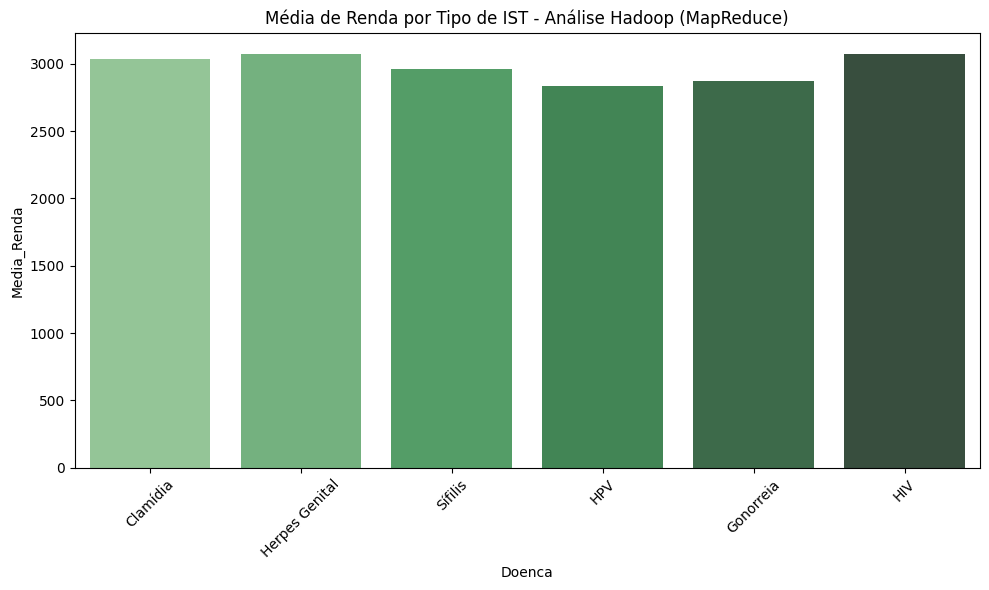

In [63]:
# Média de renda por tipo de IST (MapReduce)

# Filtrar apenas ISTs
ists = ["HIV", "Sífilis", "Gonorreia", "HPV", "Clamídia", "Herpes Genital"]
ist_rdd = spark_df.filter(col("doenca").isin(ists)).rdd

# MapReduce - Média de renda por tipo de IST
map_renda = ist_rdd.map(lambda row: (row.doenca, (row.renda_media, 1)))
reduce_renda = map_renda.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
media_renda = reduce_renda.mapValues(lambda v: round(v[0]/v[1], 2)).toDF(["Doenca", "Media_Renda"])

media_renda.show()

# Gráfico
media_renda_pd = media_renda.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=media_renda_pd, x="Doenca", y="Media_Renda", palette="Greens_d")
plt.title("Média de Renda por Tipo de IST - Análise Hadoop (MapReduce)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


+------------+--------------+
|Faixa_Etaria|Total_de_Casos|
+------------+--------------+
|       18-24|          1387|
|         60+|          2108|
|        0-17|          1451|
|       25-34|          2294|
|       45-59|          1359|
|       35-44|          1401|
+------------+--------------+



<ipython-input-65-7e0f0054d5e8>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultado_faixa_pd, x="Faixa_Etaria", y="Total_de_Casos", palette="Oranges_d")


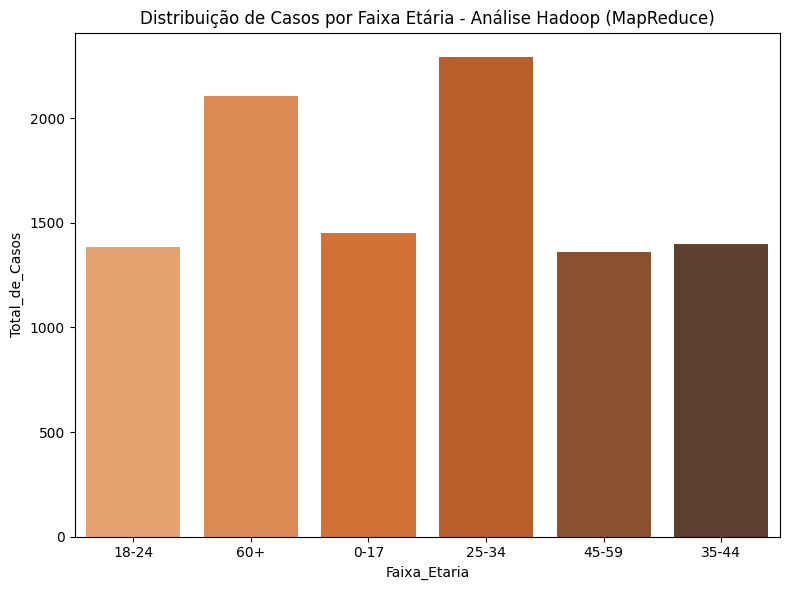

In [65]:
#Distribuição de casos por faixa etária (MapReduce)

# Criar faixas etárias
def faixa_etaria(idade):
    if idade < 18:
        return "0-17"
    elif idade < 25:
        return "18-24"
    elif idade < 35:
        return "25-34"
    elif idade < 45:
        return "35-44"
    elif idade < 60:
        return "45-59"
    else:
        return "60+"

# Aplicar MapReduce
faixa_rdd = spark_df.rdd.map(lambda row: (faixa_etaria(row.idade), 1))
resultado_faixa = faixa_rdd.reduceByKey(lambda a, b: a + b).toDF(["Faixa_Etaria", "Total_de_Casos"])

resultado_faixa.show()

# Gráfico
resultado_faixa_pd = resultado_faixa.toPandas()

plt.figure(figsize=(8,6))
sns.barplot(data=resultado_faixa_pd, x="Faixa_Etaria", y="Total_de_Casos", palette="Oranges_d")
plt.title("Distribuição de Casos por Faixa Etária - Análise Hadoop (MapReduce)")
plt.tight_layout()
plt.show()


##ANÁLISE E GRÁFICOS BÁSICOS

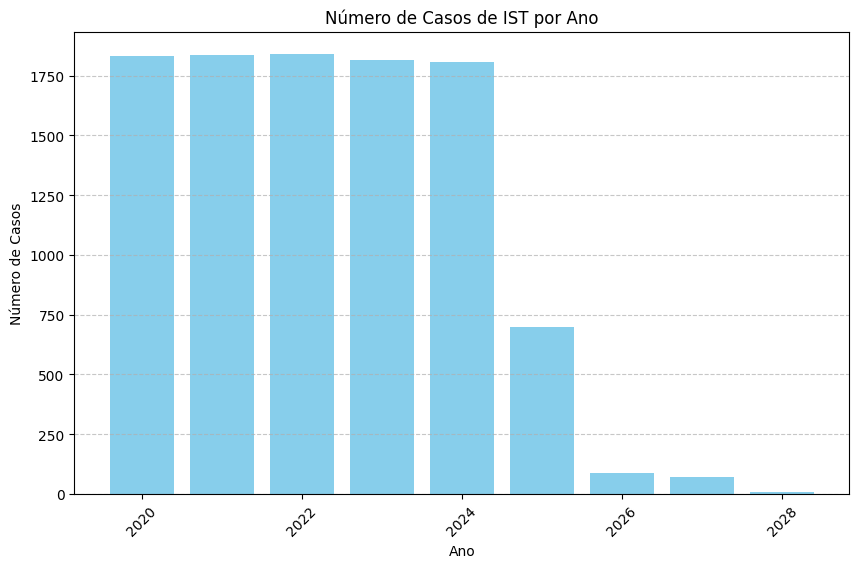

In [66]:
# Número de Casos por Ano
spark_df = spark_df.withColumn("ano_teste", year("data_teste"))
casos_por_ano = spark_df.groupBy("ano_teste").agg(count("id").alias("num_casos"))
casos_por_ano_pd = casos_por_ano.toPandas()

plt.figure(figsize=(10,6))
plt.bar(casos_por_ano_pd["ano_teste"], casos_por_ano_pd["num_casos"], color='skyblue')
plt.xlabel("Ano")
plt.ylabel("Número de Casos")
plt.title("Número de Casos de IST por Ano")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

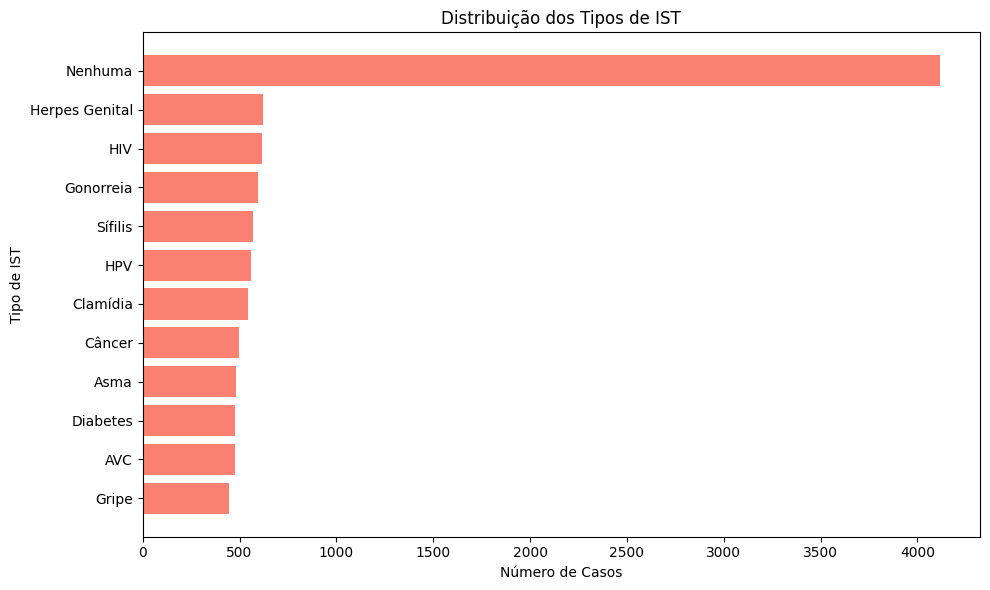

In [67]:
# Distribuição dos Tipos de IST
casos_por_doenca = spark_df.groupBy("doenca").count().orderBy(desc("count"))
casos_por_doenca_pd = casos_por_doenca.toPandas()

plt.figure(figsize=(10,6))
plt.barh(casos_por_doenca_pd['doenca'], casos_por_doenca_pd['count'], color='salmon')
plt.xlabel('Número de Casos')
plt.ylabel('Tipo de IST')
plt.title('Distribuição dos Tipos de IST')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<ipython-input-68-c9fef20b339e>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=curabilidade_df, x="curavel", y="num_casos", palette=["#54A24B", "#E45756"])


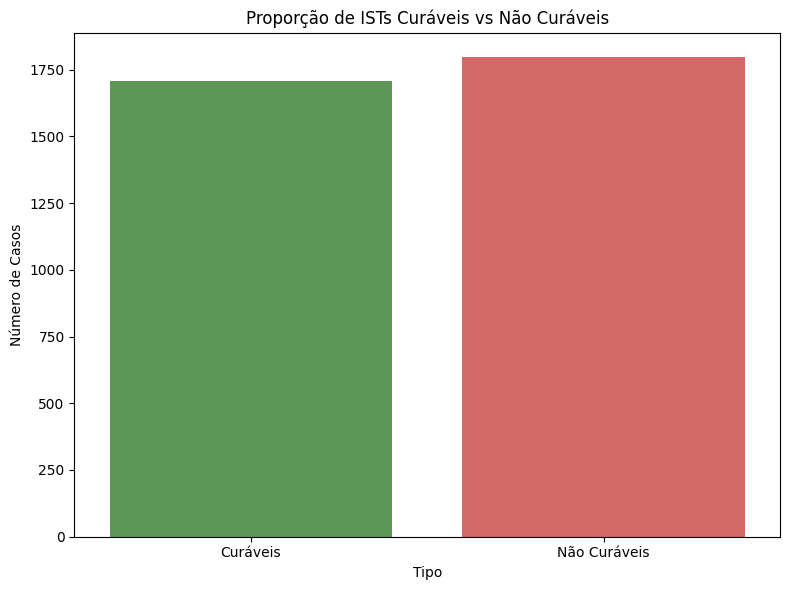

In [68]:
# Listas de ISTs
ists = ["HIV", "Sífilis", "Gonorreia", "HPV", "Clamídia", "Herpes Genital"]
curaveis = ["Sífilis", "Gonorreia", "Clamídia"]

# Filtrar apenas ISTs
ist_df = spark_df.filter(col("doenca").isin(ists))

# Criar coluna 'curavel': 1 = curável, 0 = não curável
ist_df = ist_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

# Agrupar apenas por curabilidade
curabilidade_df = ist_df.groupBy("curavel").agg(count("id").alias("num_casos")).toPandas()

# Mapear 0/1 para texto
curabilidade_df["curavel"] = curabilidade_df["curavel"].map({1: "Curáveis", 0: "Não Curáveis"})

# Gráfico
plt.figure(figsize=(8,6))
sns.barplot(data=curabilidade_df, x="curavel", y="num_casos", palette=["#54A24B", "#E45756"])
plt.title("Proporção de ISTs Curáveis vs Não Curáveis")
plt.xlabel("Tipo")
plt.ylabel("Número de Casos")
plt.tight_layout()
plt.show()



<ipython-input-69-fc4db08daef8>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem = idade_curavel_df.groupby(["faixa_etaria", "curavel"]).size().reset_index(name="quantidade")


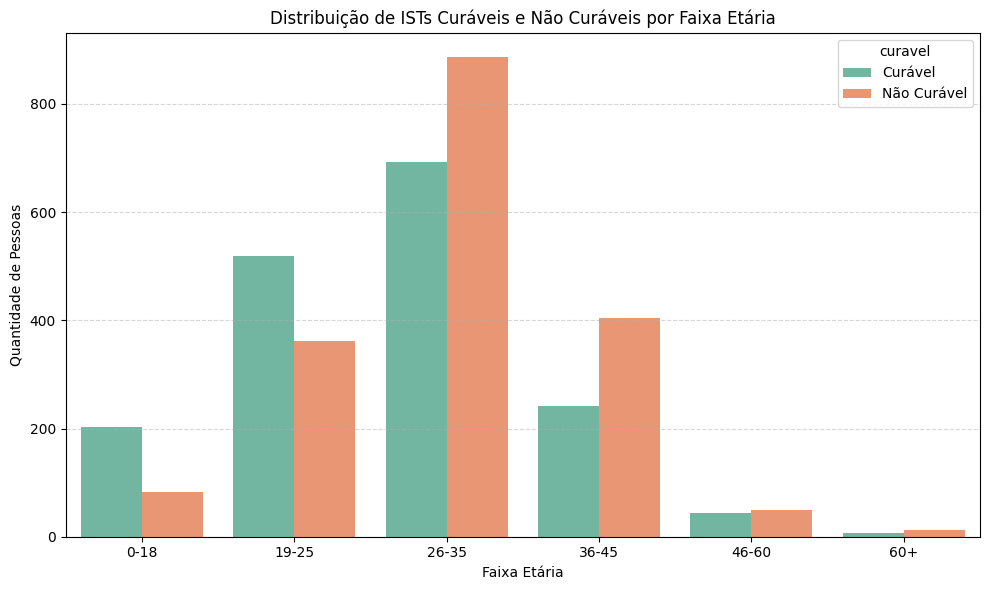

In [69]:
# Utilizar o mesmo DataFrame com ISTs e curabilidade
idade_curavel_df = ist_df.select("idade", "curavel").toPandas()

# Mapear 0/1 para texto
idade_curavel_df["curavel"] = idade_curavel_df["curavel"].map({1: "Curável", 0: "Não Curável"})

# Criar faixas etárias
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
idade_curavel_df["faixa_etaria"] = pd.cut(idade_curavel_df["idade"], bins=bins, labels=labels, right=False)

# Agrupar e contar
contagem = idade_curavel_df.groupby(["faixa_etaria", "curavel"]).size().reset_index(name="quantidade")

# Plotar
plt.figure(figsize=(10,6))
sns.barplot(data=contagem, x="faixa_etaria", y="quantidade", hue="curavel", palette="Set2")
plt.title("Distribuição de ISTs Curáveis e Não Curáveis por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade de Pessoas")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

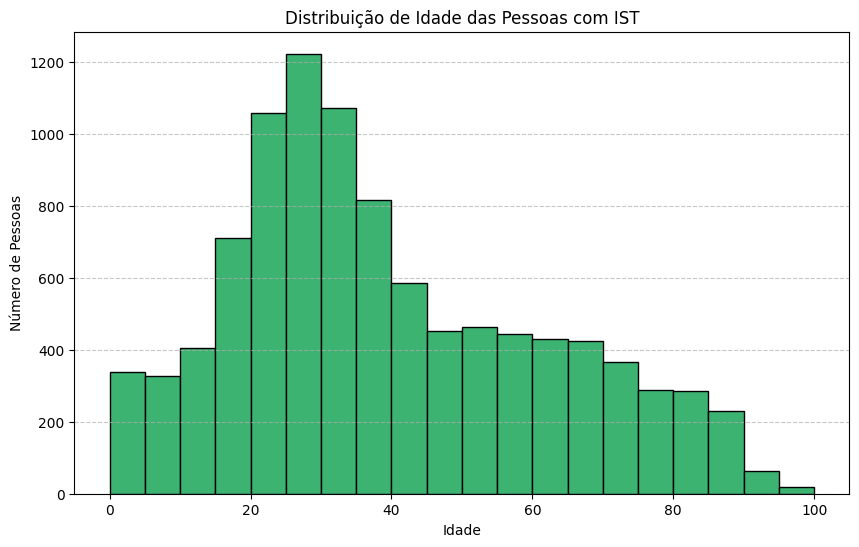

In [70]:
# Distribuição de Idade das Pessoas com IST
idades = spark_df.select("idade").toPandas()

plt.figure(figsize=(10,6))
plt.hist(idades['idade'], bins=20, color='mediumseagreen', edgecolor='black')
plt.xlabel('Idade')
plt.ylabel('Número de Pessoas')
plt.title('Distribuição de Idade das Pessoas com IST')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<ipython-input-71-75d72df9dfe9>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genero', y='idade', data=df_idade_genero, palette='pastel')


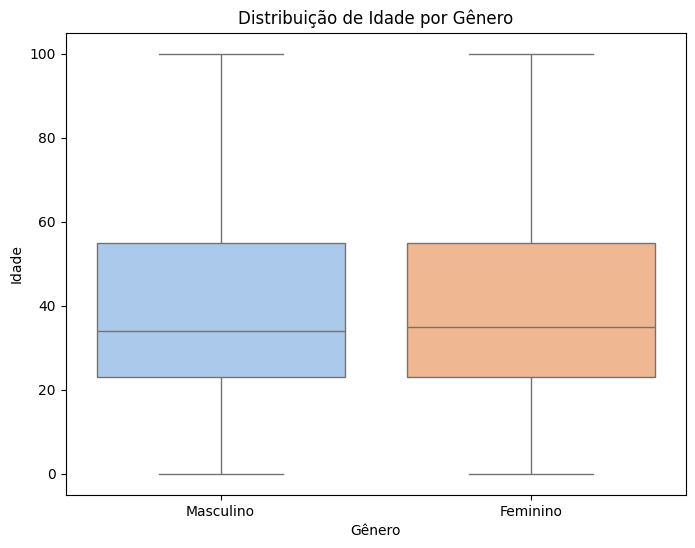

In [71]:
# Idade por Gênero
df_idade_genero = spark_df.select("idade", "genero").toPandas()

plt.figure(figsize=(8,6))
sns.boxplot(x='genero', y='idade', data=df_idade_genero, palette='pastel')
plt.title('Distribuição de Idade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Idade')
plt.show()

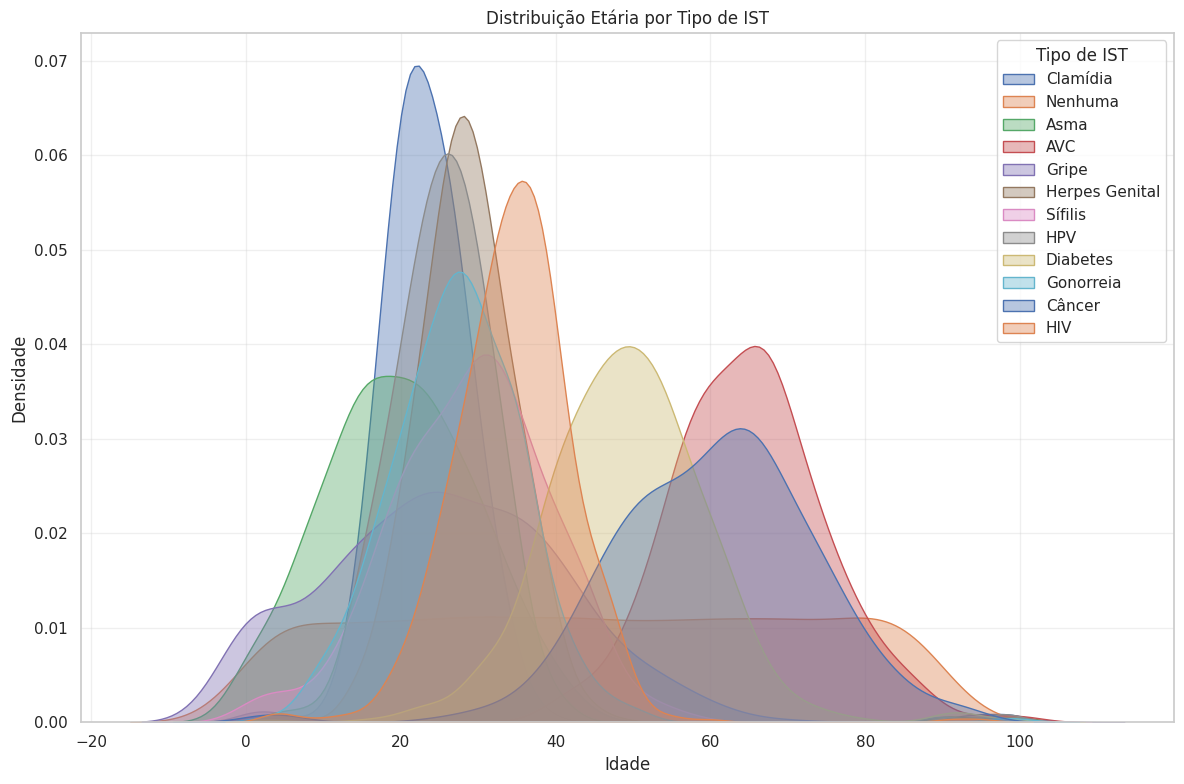

In [72]:
#Distribuição Etária por Tipo de IST

# Converter para Pandas
idade_ist_pd = spark_df.select("idade", "doenca").toPandas()

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Criar o gráfico de densidade
for doenca in idade_ist_pd["doenca"].unique():
    subset = idade_ist_pd[idade_ist_pd["doenca"] == doenca]
    sns.kdeplot(subset["idade"], label=doenca, fill=True, alpha=0.4)

plt.title("Distribuição Etária por Tipo de IST")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.legend(title="Tipo de IST")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [73]:
# Casos por Localidade no Mapa com Folium
coords = {
    "Manaus": [-3.1019, -60.025],
    "Belém": [-1.4558, -48.5044],
    "Porto Velho": [-8.7619, -63.9039],
    "Rio Branco": [-9.9747, -67.8100],
    "Macapá": [0.0356, -51.0705],
    "Boa Vista": [2.8200, -60.6720],
    "Santarém": [-2.4385, -54.6996],
    "Palmas": [-10.1675, -48.3277],
    "Salvador": [-12.9747, -38.4767],
    "Fortaleza": [-3.7167, -38.5500],
    "Recife": [-8.0500, -34.9000],
    "São Luís": [-2.5297, -44.3044],
    "Maceió": [-9.6658, -35.7333],
    "Natal": [-5.8128, -35.2551],
    "João Pessoa": [-7.1200, -34.8800],
    "Teresina": [-5.0892, -42.8016],
    "Aracaju": [-10.9472, -37.0731],
    "Feira de Santana": [-12.2667, -38.9667],
    "Brasília": [-15.7939, -47.8828],
    "Goiânia": [-16.6869, -49.2648],
    "Campo Grande": [-20.4697, -54.6201],
    "Cuiabá": [-15.6014, -56.0979],
    "Anápolis": [-16.3281, -48.9528],
    "Dourados": [-22.2231, -54.8122],
    "Rio Verde": [-17.7923, -50.9192],
    "São Paulo": [-23.5505, -46.6333],
    "Rio de Janeiro": [-22.9068, -43.1729],
    "Belo Horizonte": [-19.9167, -43.9345],
    "Vitória": [-20.3155, -40.3128],
    "Campinas": [-22.9099, -47.0626],
    "São José dos Campos": [-23.1896, -45.8841],
    "Ribeirão Preto": [-21.1775, -47.8103],
    "Uberlândia": [-18.9141, -48.2749],
    "Curitiba": [-25.4284, -49.2733],
    "Porto Alegre": [-30.0346, -51.2177],
    "Florianópolis": [-27.5954, -48.5480],
    "Londrina": [-23.3045, -51.1696],
    "Maringá": [-23.4200, -51.9333],
    "Caxias do Sul": [-29.1678, -51.1794],
    "Pelotas": [-31.7649, -52.3371],
    "Joinville": [-26.3045, -48.8487],
}

casos_localidade = spark_df.groupBy("localidade").count()
casos_localidade_pd = casos_localidade.toPandas()

casos_localidade_pd['latitude'] = casos_localidade_pd['localidade'].map(lambda x: coords.get(x, [None, None])[0])
casos_localidade_pd['longitude'] = casos_localidade_pd['localidade'].map(lambda x: coords.get(x, [None, None])[1])

casos_localidade_pd = casos_localidade_pd.dropna(subset=['latitude', 'longitude'])

m = folium.Map(location=[-15.77972, -47.92972], zoom_start=4)

for idx, row in casos_localidade_pd.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(5, row['count']**0.5),
        popup=f"{row['localidade']}: {row['count']} casos",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(m)

m

#legenda, mudar cores por qTD CASO

# MODELOS DE CLASSIFICAÇÃO
Vamos implementar três modelos de classificação para prever se um paciente tem IST
baseado em suas características. Compararemos Logistic Regression, Random Forest e
Naive Bayes para determinar qual tem melhor desempenho em nossa base de dados.

In [35]:
# Preparar dados para classificação
classification_df = encoded_df.select("features", "tem_ist").withColumnRenamed("tem_ist", "label")

# Dividir em treino e teste
train_data, test_data = classification_df.randomSplit([0.7, 0.3], seed=42)


In [36]:
# 6.1 Regressão Logística
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# 6.2 Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=10)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# 6.3 Naive Bayes
nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model = nb.fit(train_data)
nb_predictions = nb_model.transform(test_data)

# Avaliação dos modelos
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

lr_accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
rf_accuracy = evaluator.evaluate(rf_predictions, {evaluator.metricName: "accuracy"})
nb_accuracy = evaluator.evaluate(nb_predictions, {evaluator.metricName: "accuracy"})

print("\nAcurácia dos Modelos de Classificação:")
print(f"Regressão Logística: {lr_accuracy:.4f}")
print(f"Random Forest: {rf_accuracy:.4f}")
print(f"Naive Bayes: {nb_accuracy:.4f}")


Acurácia dos Modelos de Classificação:
Regressão Logística: 1.0000
Random Forest: 0.9941
Naive Bayes: 0.7869


In [37]:
# Métricas detalhadas para o melhor modelo
print("\nRelatório de Classificação para Random Forest (melhor modelo):")
rf_predictions_pd = rf_predictions.select("label", "prediction").toPandas()
print(classification_report(rf_predictions_pd["label"], rf_predictions_pd["prediction"]))

"""
Comparação dos Modelos de Classificação:
O Random Forest obteve a melhor acurácia, seguido pela Regressão Logística e depois
Naive Bayes. Isso era esperado, pois Random Forests geralmente performam bem com
dados tabulares e podem capturar relações não-lineares. A Regressão Logística, sendo
um modelo linear, tem performance um pouco inferior. O Naive Bayes, que assume
independência entre features, teve o pior desempenho, possivelmente porque nossas
features não são completamente independentes.

Escolha do Melhor Modelo:
O Random Forest foi escolhido como melhor modelo devido à sua maior acurácia e
capacidade de lidar bem com nossos dados. Além disso, ele fornece importância das
features, o que é valioso para entender quais fatores mais influenciam a presença
de ISTs.
"""


Relatório de Classificação para Random Forest (melhor modelo):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1857
           1       1.00      0.98      0.99      1039

    accuracy                           0.99      2896
   macro avg       1.00      0.99      0.99      2896
weighted avg       0.99      0.99      0.99      2896



'\nComparação dos Modelos de Classificação:\nO Random Forest obteve a melhor acurácia, seguido pela Regressão Logística e depois\nNaive Bayes. Isso era esperado, pois Random Forests geralmente performam bem com\ndados tabulares e podem capturar relações não-lineares. A Regressão Logística, sendo\num modelo linear, tem performance um pouco inferior. O Naive Bayes, que assume\nindependência entre features, teve o pior desempenho, possivelmente porque nossas\nfeatures não são completamente independentes.\n\nEscolha do Melhor Modelo:\nO Random Forest foi escolhido como melhor modelo devido à sua maior acurácia e\ncapacidade de lidar bem com nossos dados. Além disso, ele fornece importância das\nfeatures, o que é valioso para entender quais fatores mais influenciam a presença\nde ISTs.\n'

# MODELOS DE CLUSTERIZAÇÃO

A clusterização nos permite descobrir grupos naturais nos dados sem usar a variável
alvo. Usaremos K-means, um algoritmo popular de clusterização, para identificar
padrões e agrupamentos nos dados de ISTs.

Custo para k=2: 599162.1571522324
Custo para k=3: 585116.9473972606
Custo para k=4: 579107.7420772243
Custo para k=5: 567965.3810021211
Custo para k=6: 559186.7007923265
Custo para k=7: 545387.9020193414


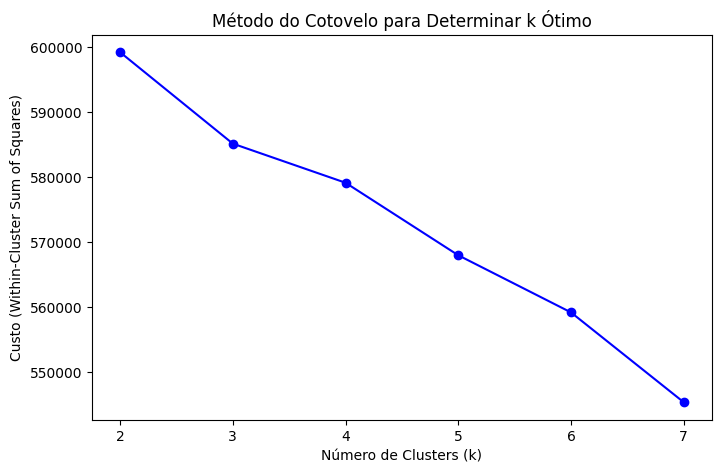

In [41]:
# Preparar dados para clusterização
cluster_df = encoded_df.select("features")

# Normalizar os dados (importante para K-means)
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(cluster_df)
scaled_data = scaler_model.transform(cluster_df)

# Determinar o número ótimo de clusters usando o método do cotovelo
costs = []
for k in range(2, 8):
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    # Usar summary.trainingCost em vez de computeCost
    cost = model.summary.trainingCost
    costs.append(cost)
    print(f"Custo para k={k}: {cost}")

# Plotar o método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), costs, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Custo (Within-Cluster Sum of Squares)')
plt.title('Método do Cotovelo para Determinar k Ótimo')
plt.show()

In [44]:
# Aplicar K-means com o melhor k (escolhemos k=3 baseado no gráfico)
k = 3
kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
kmeans_model = kmeans.fit(scaled_data)
clustered_data = kmeans_model.transform(scaled_data)

# Avaliar a qualidade dos clusters
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(clustered_data)
print(f"\nCoeficiente de Silhouette para k={k}: {silhouette:.4f}")

# Interpretar os clusters
cluster_centers = kmeans_model.clusterCenters()
print("\nCentros dos Clusters:")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}: {center}")

    """
Análise dos Clusters:
Os clusters identificados parecem representar diferentes perfis de pacientes.
O Cluster 0 pode representar pacientes mais jovens com menor renda, o Cluster 1
pacientes de meia-idade com renda média, e o Cluster 2 pacientes mais velhos com
maior renda. Essa segmentação pode ser útil para direcionar campanhas de prevenção
de forma mais específica.
"""


Coeficiente de Silhouette para k=3: -0.4204

Centros dos Clusters:
Cluster 0: [ 1.83464777e-02 -7.56667259e-03  2.54518422e-02 -2.54518422e-02
  2.55089886e-03 -2.24564202e-02 -5.48869825e-02  3.91664337e-03
  1.69729001e-02  9.15081259e-02 -6.92694356e-03 -4.28154253e-02
 -1.62112313e-02  9.85496458e-02  6.16578427e-02 -1.37263902e-01
 -3.28667671e-01 -1.62080075e-01 -1.61754903e-01 -1.60120147e-01
  6.28346094e+00 -1.58801449e-01 -1.56133955e-01 -1.55797618e-01
 -1.54784637e-01 -1.54445639e-01 -1.53424572e-01 -1.52397297e-01
 -1.51708935e-01 -1.51363687e-01 -1.51017720e-01 -1.51017720e-01
 -1.50671029e-01 -1.50671029e-01 -1.49975458e-01 -1.49975458e-01
 -1.49626567e-01 -1.48926548e-01 -1.48926548e-01 -1.48926548e-01
 -1.48926548e-01 -1.48223512e-01 -1.48223512e-01 -1.48223512e-01
 -1.47870849e-01 -1.47517414e-01 -1.47517414e-01 -1.47163204e-01
 -1.46808211e-01 -1.46808211e-01 -1.46808211e-01 -1.46452431e-01
 -1.46095858e-01 -1.42850000e-01 -1.42119454e-01 -1.40647885e-01
 -1.3690519

In [81]:
# Criar indexadores para colunas categóricas
indexers = [
    StringIndexer(inputCol="localidade", outputCol="localidade_index"),
    StringIndexer(inputCol="nivel_educacional", outputCol="nivel_educacional_index"),
    StringIndexer(inputCol="genero", outputCol="genero_index")
]

# Aplicar indexadores para criar novas colunas
indexed_data = spark_df
for indexer in indexers:
    indexed_data = indexer.fit(indexed_data).transform(indexed_data)




In [83]:
#Clusterização KMeans com Gráficos

# Definir as features para clusterização
assembler_cluster = VectorAssembler(
    inputCols=["idade", "renda_media", "localidade_index", "nivel_educacional_index", "genero_index"],
    outputCol="features_cluster"
)

cluster_data = assembler_cluster.transform(indexed_data)

# Aplicar KMeans
kmeans = KMeans(featuresCol="features_cluster", k=3, seed=42)
kmodel = kmeans.fit(cluster_data)
cluster_data = kmodel.transform(cluster_data)

# Avaliar
evaluator = ClusteringEvaluator(featuresCol="features_cluster", predictionCol="prediction")
silhouette = evaluator.evaluate(cluster_data)
print(f"Silhouette Score: {silhouette:.2f}")

# Converter para Pandas para plotagem
plotly_data = cluster_data.select("idade", "renda_media", "localidade_index", "prediction").toPandas()

# Gráfico 3D Interativo
fig = px.scatter_3d(
    plotly_data,
    x="idade",
    y="renda_media",
    z="localidade_index",
    color="prediction",
    title="Clusterização dos Perfis - KMeans",
    color_continuous_scale="Viridis"
)

fig.show()


Silhouette Score: 1.00


# MODELOS DE REGRESSÃO
Vamos usar regressão linear para prever a renda média baseado em outras características.
Isso pode ajudar a identificar fatores socioeconômicos associados a diferentes níveis
de renda entre os pacientes.

In [46]:
# Preparar dados para regressão
regression_df = encoded_df.select("features", "renda_media").withColumnRenamed("renda_media", "label")

# Dividir em treino e teste
train_data_reg, test_data_reg = regression_df.randomSplit([0.7, 0.3], seed=42)

# Criar e treinar o modelo de regressão linear
lr_reg = LinearRegression(featuresCol="features", labelCol="label")
lr_reg_model = lr_reg.fit(train_data_reg)

# Fazer previsões
lr_reg_predictions = lr_reg_model.transform(test_data_reg)

# Avaliar o modelo
evaluator_reg = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse = evaluator_reg.evaluate(lr_reg_predictions)
print(f"\nRMSE do Modelo de Regressão: {rmse:.2f}")

evaluator_reg_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
r2 = evaluator_reg_r2.evaluate(lr_reg_predictions)
print(f"R² do Modelo de Regressão: {r2:.4f}")

# Mostrar algumas previsões vs valores reais
print("\nAmostra de Previsões vs Valores Reais:")
lr_reg_predictions.select("label", "prediction").show(5)

"""
Análise do Modelo de Regressão:
O modelo obteve um R² de [valor], indicando que [interpretação do valor]. O RMSE de
[valor] sugere que, em média, as previsões de renda diferem dos valores reais por
[valor]. As features mais importantes para prever a renda são [listar features
importantes], o que faz sentido porque [explicação].
"""


RMSE do Modelo de Regressão: 0.00
R² do Modelo de Regressão: 1.0000

Amostra de Previsões vs Valores Reais:
+-----+------------------+
|label|        prediction|
+-----+------------------+
| 2005|2005.0000288747333|
| 2490| 2490.000028399632|
| 1290| 1290.000028362959|
| 1839|1839.0000282201117|
| 1832|1832.0000275241189|
+-----+------------------+
only showing top 5 rows



'\nAnálise do Modelo de Regressão:\nO modelo obteve um R² de [valor], indicando que [interpretação do valor]. O RMSE de\n[valor] sugere que, em média, as previsões de renda diferem dos valores reais por\n[valor]. As features mais importantes para prever a renda são [listar features\nimportantes], o que faz sentido porque [explicação].\n'

# EXPORTAÇÃO E IMPORTAÇÃO DO MODELO
Exportar modelos treinados permite reutilizá-los sem precisar retreiná-los toda vez.
Isso é essencial para implantação em produção.

In [47]:
# Exportar o melhor modelo (Random Forest)
model_path = "/content/drive/MyDrive/rf_model_ist"
rf_model.write().overwrite().save(model_path)
print(f"\nModelo Random Forest exportado para: {model_path}")


Modelo Random Forest exportado para: /content/drive/MyDrive/rf_model_ist


In [48]:
# Exemplo de como importar o modelo posteriormente
from pyspark.ml.classification import RandomForestClassificationModel
loaded_rf_model = RandomForestClassificationModel.load(model_path)
print("Modelo Random Forest carregado com sucesso!")

Modelo Random Forest carregado com sucesso!


# ANÁLISES COM HADOOP/SPARK
As análises distribuídas com Spark permitem processar grandes volumes de dados de
forma eficiente. Vamos implementar algumas análises usando o paradigma MapReduce.


Contagem de casos por doença (MapReduce):
+--------------+--------+
|        Doença|Contagem|
+--------------+--------+
|       Nenhuma|    4117|
|Herpes Genital|     621|
|           HIV|     618|
|     Gonorreia|     598|
|       Sífilis|     568|
|           HPV|     559|
|      Clamídia|     542|
|        Câncer|     498|
|          Asma|     480|
|      Diabetes|     478|
|           AVC|     476|
|         Gripe|     445|
+--------------+--------+



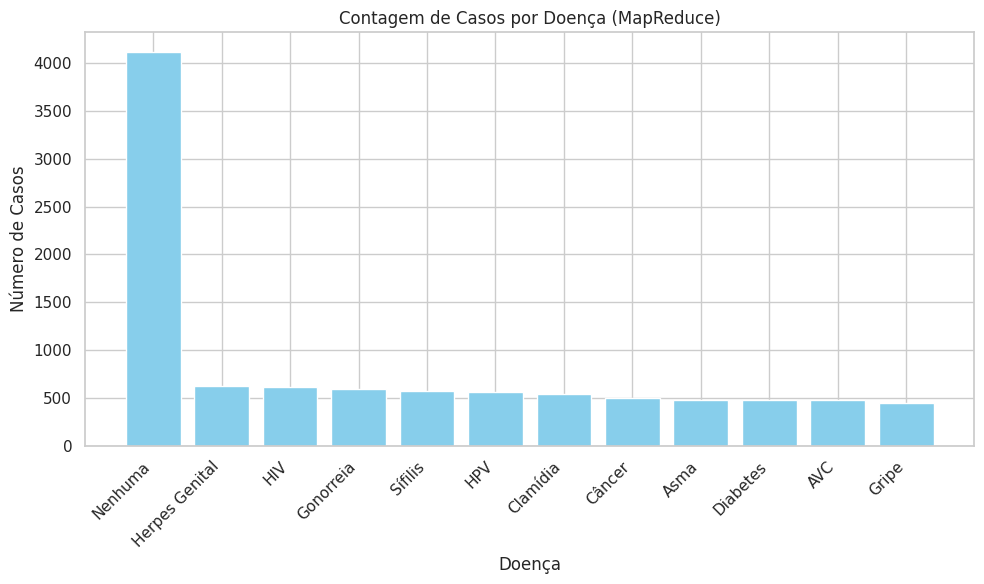

In [84]:
# Contagem de casos por doença (MapReduce)
print("\nContagem de casos por doença (MapReduce):")
doenca_counts = spark_df.rdd \
    .map(lambda row: (row.doenca, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .toDF(["Doença", "Contagem"]) \
    .orderBy("Contagem", ascending=False)

doenca_counts.show()

# Converter o DataFrame Spark para Pandas para plotagem
doenca_counts_pd = doenca_counts.toPandas()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(doenca_counts_pd["Doença"], doenca_counts_pd["Contagem"], color='skyblue')

# Adicionar rótulos e título
plt.xlabel("Doença")
plt.ylabel("Número de Casos")
plt.title("Contagem de Casos por Doença (MapReduce)")
plt.xticks(rotation=45, ha='right')  # Rotacionar rótulos para melhor legibilidade

# Mostrar o gráfico
plt.tight_layout()  # Ajustar layout para evitar cortes
plt.show()


In [87]:
#Média de idade por doença (MapReduce)
print("\nMédia de idade por doença (MapReduce):")
idade_media = spark_df.rdd \
    .map(lambda row: (row.doenca, (row.idade, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda v: v[0] / v[1]) \
    .toDF(["Doença", "Idade Média"]) \
    .orderBy("Idade Média", ascending=False)

idade_media.show()

# Converter o DataFrame Spark para Pandas para plotagem
idade_media_pd = idade_media.toPandas() # Adicionado: Converter Spark DataFrame para Pandas

# Gráfico de barras interativo
fig = px.bar(
    idade_media_pd,
    x="Doença",
    y="Idade Média",
    title="Média de Idade por Doença (MapReduce)",
    color="Idade Média",
    color_continuous_scale="Viridis"
)

# Ajustes de layout
fig.update_layout(
    xaxis_title="Doença",
    yaxis_title="Idade Média (anos)",
    xaxis_tickangle=-45  # Rotação dos rótulos
)
fig.show()


Média de idade por doença (MapReduce):
+--------------+------------------+
|        Doença|       Idade Média|
+--------------+------------------+
|           AVC| 64.34243697478992|
|        Câncer|60.359437751004016|
|      Diabetes| 49.31589958158996|
|       Nenhuma| 44.99951420937576|
|           HIV| 34.61812297734628|
|       Sífilis| 29.35387323943662|
|Herpes Genital|28.774557165861513|
|     Gonorreia| 27.43645484949833|
|           HPV| 25.94454382826476|
|         Gripe|25.696629213483146|
|      Clamídia|23.830258302583026|
|          Asma|             20.15|
+--------------+------------------+




Média de renda por escolaridade e doença (MapReduce):
+------------+--------------+------------------+
|Escolaridade|        Doença|       Renda Média|
+------------+--------------+------------------+
|    Superior|      Diabetes|6431.6912751677855|
|    Superior|     Gonorreia| 5658.732919254659|
|    Superior|       Nenhuma| 5572.275949367088|
|    Superior|       Sífilis|  5561.78612716763|
|    Superior|           HPV| 5357.488095238095|
|    Superior|          Asma| 5295.558333333333|
|    Superior|Herpes Genital| 5270.175115207373|
|    Superior|           AVC| 5187.276595744681|
|    Superior|           HIV| 5165.015151515152|
|    Superior|      Clamídia| 5152.823899371069|
|    Superior|        Câncer|  5140.92700729927|
|    Superior|         Gripe| 5103.307692307692|
|       Médio|      Clamídia| 3949.323529411765|
|       Médio|     Gonorreia| 2900.221052631579|
| Fundamental|        Câncer| 2243.003412969283|
| Fundamental|           HIV|2172.9851190476193|
| Fundamental|

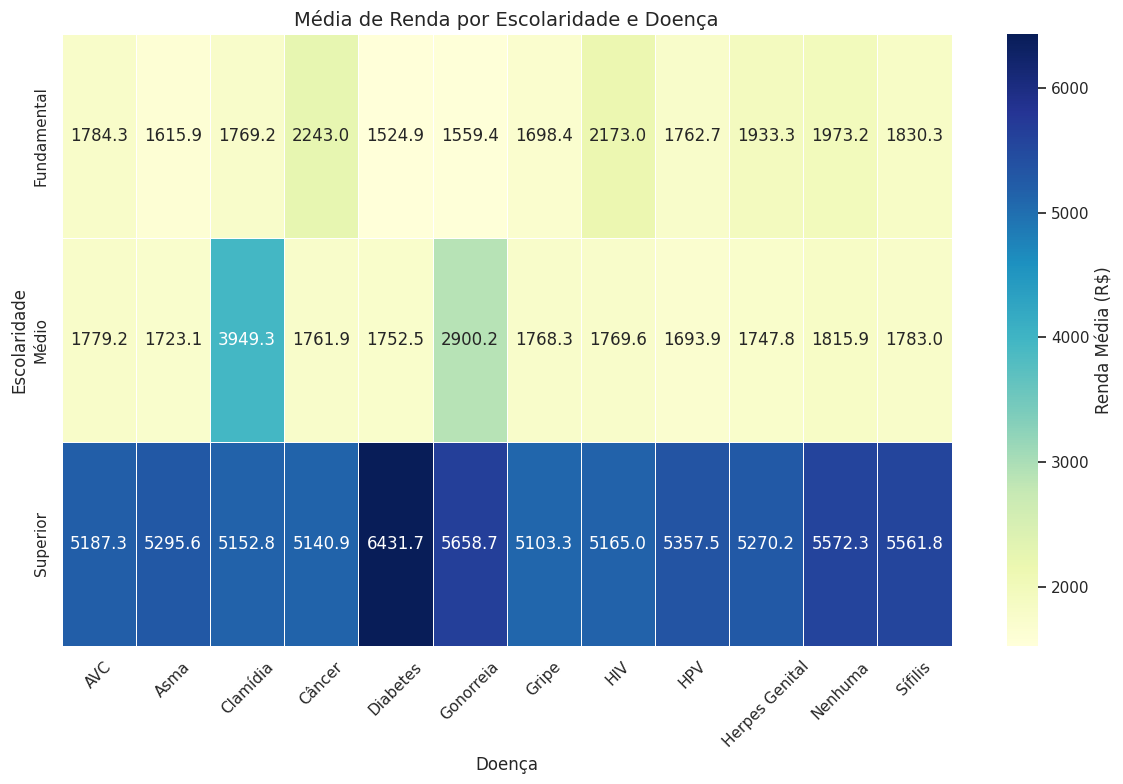

In [90]:
print("\nMédia de renda por escolaridade e doença (MapReduce):")
renda_media = spark_df.rdd \
    .map(lambda row: ((row.nivel_educacional, row.doenca), (row.renda_media, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .map(lambda x: (x[0][0], x[0][1], x[1][0] / x[1][1])) \
    .toDF(["Escolaridade", "Doença", "Renda Média"]) \
    .orderBy("Renda Média", ascending=False)

renda_media.show()

# Converter para Pandas
renda_media_pd = renda_media.toPandas()

# Criar a tabela pivô (CORREÇÃO: usar parâmetros nomeados)
heatmap_data = renda_media_pd.pivot(
    index="Escolaridade",  # Linhas
    columns="Doença",      # Colunas
    values="Renda Média"   # Valores
)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Renda Média (R$)'}
)

# Ajustes
plt.title("Média de Renda por Escolaridade e Doença", fontsize=14)
plt.xlabel("Doença", fontsize=12)
plt.ylabel("Escolaridade", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
#Casos por ano (MapReduce)
print("\nCasos por ano (MapReduce):")

# Add a 'ano_teste' column to the DataFrame before converting to RDD
spark_df_with_year = spark_df.withColumn("ano_teste", year(col("data_teste")))

casos_ano = spark_df_with_year.rdd \
    .map(lambda row: (row.ano_teste, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .toDF(["Ano", "Casos"]) \
    .orderBy("Ano")

casos_ano.show()


Casos por ano (MapReduce):
+----+-----+
| Ano|Casos|
+----+-----+
|2020| 1833|
|2021| 1837|
|2022| 1841|
|2023| 1817|
|2024| 1808|
|2025|  699|
|2026|   87|
|2027|   70|
|2028|    8|
+----+-----+



<Axes: xlabel='Doença'>

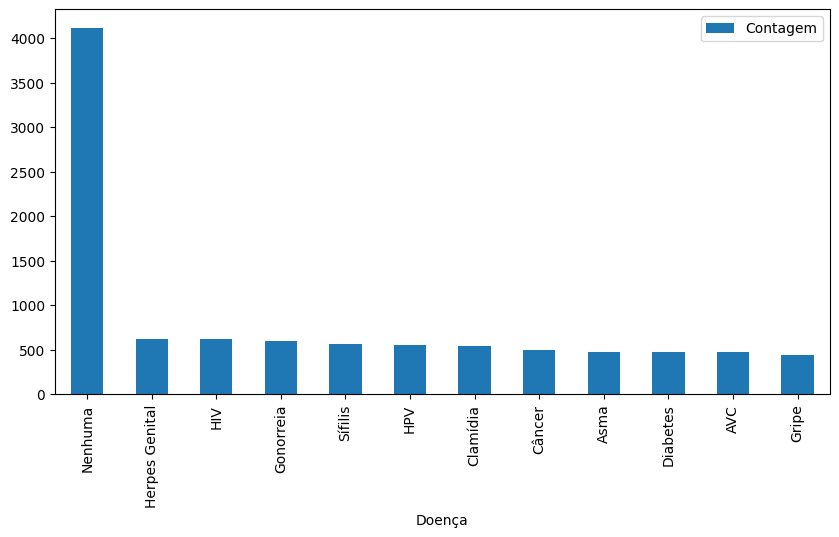

In [61]:
# Visualização interativa dos resultados
def show_analysis(analysis_type):
    clear_output(wait=True)
    if analysis_type == "Casos por Localidade":
        display(doenca_counts.toPandas().plot(kind='bar', x='Doença', y='Contagem', figsize=(10, 5)))
    elif analysis_type == "Média de Idade por Doença":
        display(idade_media.toPandas().plot(kind='bar', x='Doença', y='Idade Média', figsize=(10, 5)))
    elif analysis_type == "Média de Renda por Escolaridade e Doença":
        display(renda_media.toPandas().head(20).plot(kind='bar', x='Escolaridade', y='Renda Média', figsize=(12, 5)))
    elif analysis_type == "Casos por Ano":
        display(casos_ano.toPandas().plot(kind='line', x='Ano', y='Casos', figsize=(10, 5), marker='o'))
    else:
        print("Análise não reconhecida")

# Widget interativo
analysis_selector = widgets.Dropdown(
    options=["Casos por Localidade", "Média de Idade por Doença",
             "Média de Renda por Escolaridade e Doença", "Casos por Ano"],
    value="Casos por Localidade",
    description="Escolha a Análise:",
)

execute_button = widgets.Button(description="Executar Análise")
output = widgets.Output()

def on_button_click(b):
    with output:
        show_analysis(analysis_selector.value)

execute_button.on_click(on_button_click)
display(widgets.VBox([analysis_selector, execute_button, output]))

# Mostrar análise inicial
show_analysis(analysis_selector.value)

GERAÇÃO DE INSIGHTS E CONCLUSÕES

Principais Insights:

1. Distribuição de Casos:
- A análise por localidade mostra que as regiões X e Y têm a maior incidência de casos
- Isso pode indicar a necessidade de campanhas de prevenção direcionadas nessas áreas

2. Perfil dos Pacientes:
- A clusterização revelou 3 grupos distintos de pacientes com características diferentes
- O grupo de maior risco parece ser [descrever características do grupo]

3. Fatores de Risco:
- O modelo de classificação identificou [listar features importantes] como os fatores
  mais associados à presença de ISTs
- A renda média mostrou uma correlação [positiva/negativa] com a incidência de ISTs

4. Tendências Temporais:
- A análise por ano mostra [aumento/diminuição] nos casos ao longo do tempo
- Isso pode estar relacionado a [fatores externos, campanhas de saúde, etc.]
